# 🎯 YuNet + EdgeFace Evaluation Pipeline



Evaluates the **YuNet + EdgeFace Evaluation Pipeline** pipeline on the LFW public dataset.



Provides a 1:1 comparison to the YuNet+FaceNet and RT-DETR+ViT benchmarks.


In [18]:
import os
import sys
import shutil
import pickle
import time
import math
from pathlib import Path
from collections import defaultdict
import numpy as np
import cv2
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ----------------- PATHS -----------------
ROOT = Path(".")
LFW_ROOT = ROOT / "lfw_dataset" / "lfw-deepfunneled" / "lfw-deepfunneled"
SPLIT_ROOT = ROOT / "lfw_dataset_split"

TRAIN_DIR = SPLIT_ROOT / "train"
VAL_DIR = SPLIT_ROOT / "val"
TEST_DIR = SPLIT_ROOT / "test"

RESULTS_DIR = ROOT / "eval_results"
RESULTS_DIR.mkdir(exist_ok=True)
CACHE_FILE = ROOT / "lfw_dataset" / "yunet_edgeface_embeddings_cache.pkl"

# ----------------- HYPERPARAMETERS -----------------
MIN_IMAGES = 5
RANDOM_SEED = 42

YUNET_CONF = 0.6
EVAL_THRESHOLD = 0.5  # Cosine similarity cut-off for EdgeFace

print(f"LFW root: {LFW_ROOT.exists()}")


LFW root: True


## 1. Download Pretrained ONNX Models

YuNet and EdgeFace are deployed efficiently using ONNX and OpenCV DNN.


In [19]:
# Download YuNet (Face Detection)
YUNET_MODEL_PATH = ROOT / "face_detection_yunet_2023mar.onnx"
if not YUNET_MODEL_PATH.exists():
    print("Downloading YuNet ONNX model...")

# Download EdgeFace (Face Recognition)
EDGEFACE_MODEL_PATH = ROOT / "edgeface_s_gamma_05.onnx"
if not EDGEFACE_MODEL_PATH.exists():
    # EdgeFace official ONNX weights hosted on a public mirror for OpenCV Zoo compatibility
    
    print("Models ready!")

## 2. Dataset Splitting (70% Train, 20% Val, 10% Test)

Physically copies the images into the `lfw_dataset_split` directory while preserving class balance.


In [20]:
def physical_split_dataset(source_dir, dest_dir, min_images):
    source = Path(source_dir)
    dest = Path(dest_dir)
    
    train_d = dest / 'train'
    val_d = dest / 'val'
    test_d = dest / 'test'
    
    if test_d.exists():
        print("Dataset already split! Skipping physical copy.")
        return
        
    for d in [train_d, val_d, test_d]:
        d.mkdir(parents=True, exist_ok=True)
        
    total_train = total_val = total_test = 0
    persons_included = 0
    
    for person_dir in sorted(source.iterdir()):
        if not person_dir.is_dir(): continue
            
        images = list(person_dir.glob('*.*'))
        if len(images) < min_images:
            continue
            
        persons_included += 1
        person_name = person_dir.name
        
        # 1. Split into Train (70%) and Temp (30%)
        # For small numbers, we use floor/ceil math to ensure at least 1 image goes to val/test
        train_imgs, temp_imgs = train_test_split(images, test_size=0.30, random_state=RANDOM_SEED)
        
        # 2. Split Temp into Val (20% total) and Test (10% total)
        # 2/3 of 30% is 20%. 1/3 of 30% is 10%.
        if len(temp_imgs) < 2:
            val_imgs, test_imgs = temp_imgs, []
        else:
            val_imgs, test_imgs = train_test_split(temp_imgs, test_size=(1/3), random_state=RANDOM_SEED)
            
        def copy_imgs(imgs, split_dir):
            target_dir = split_dir / person_name
            target_dir.mkdir(parents=True, exist_ok=True)
            for img in imgs:
                shutil.copy2(img, target_dir / img.name)
            return len(imgs)
            
        total_train += copy_imgs(train_imgs, train_d)
        total_val += copy_imgs(val_imgs, val_d)
        total_test += copy_imgs(test_imgs, test_d)
        
    print('========================================')
    print(f'✅ Physical Dataset Split Completed!')
    print(f'   Persons included : {persons_included}')
    print(f'   Train images     : {total_train} (70%)')
    print(f'   Val images       : {total_val} (20%)')
    print(f'   Test images      : {total_test} (10%)')
    print('========================================')

physical_split_dataset(LFW_ROOT, SPLIT_ROOT, MIN_IMAGES)


Dataset already split! Skipping physical copy.


## 3. Load YuNet and EdgeFace

Initializes the models and sets up the inference functions.


In [21]:
# Initialize YuNet (Face Detection)
print("Loading YuNet...")
try:
    detector = cv2.FaceDetectorYN.create(
        model=str(YUNET_MODEL_PATH),
        config="",
        input_size=(320, 320), # Will dynamically resize later
        score_threshold=YUNET_CONF,
        nms_threshold=0.3,
        top_k=5000
    )
except Exception as e:
    print(f"Failed to load YuNet: {e}")

# Initialize EdgeFace using PyTorch natively
print("Loading EdgeFace...")
import sys, torch
if './edgeface' not in sys.path:
    sys.path.insert(0, './edgeface')
try:
    from backbones import get_model
    recognizer = get_model('edgeface_s_gamma_05')
    recognizer.load_state_dict(torch.load('edgeface_s_gamma_05.pt', map_location='cpu'))
    recognizer.eval()
except Exception as e:
    print(f"Failed to load EdgeFace: {e}")

print("Models initialized!")


Loading YuNet...
Loading EdgeFace...
Failed to load EdgeFace: No module named 'timm'
Models initialized!


## 4. Embedding Extraction Pipeline

Detects face -> Crops -> Extracts 512D EdgeFace feature vector.


In [22]:
def get_embedding_via_pipeline(img_path):
    start_time = time.time()
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        return None, 0, False

    h, w = img_bgr.shape[:2]

    # 1. Detect using YuNet
    detector.setInputSize((w, h))
    _, faces = detector.detect(img_bgr)

    face_crop = None
    detected = True
    if faces is not None and len(faces) > 0:
        # Grab highest confidence face
        best_face = max(faces, key=lambda f: f[-1])
        x, y, fw, fh = best_face[:4].astype(int)

        # Crop with margin
        margin = max(4, int(max(fw, fh) * 0.1))
        x1, y1 = max(0, x - margin), max(0, y - margin)
        x2, y2 = min(w, x + fw + margin), min(h, y + fh + margin)
        face_crop = img_bgr[y1:y2, x1:x2]

    if face_crop is None or face_crop.size == 0:
        # Fallback to entire image if YuNet couldn't detect anything
        face_crop = img_bgr
        detected = False

    # 2. Extract with EdgeFace using PyTorch natively
    try:
        face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
        face_resized = cv2.resize(face_rgb, (112, 112))
        blob = cv2.dnn.blobFromImage(
            face_resized,
            scalefactor=1.0 / 127.5,
            size=(112, 112),
            mean=(127.5, 127.5, 127.5),
            swapRB=False,
            crop=False
        )
        
        import torch
        with torch.no_grad():
            tensor = torch.from_numpy(blob)
            emb = recognizer(tensor).numpy()
        
        emb = emb.flatten()
        norm = np.linalg.norm(emb)
        if norm > 0:
            emb = (emb / norm).astype('float32')

    except Exception as e:
        print(f"Error during EdgeFace inference: {e}")
        return None, time.time() - start_time, False

    inference_time = time.time() - start_time
    return emb, inference_time, detected

def extract_all_pipeline(split_dir, desc=""):
    result = {}
    detect_count = {True: 0, False: 0}
    
    # Collect images
    split_path = Path(split_dir)
    persons = {}
    if split_path.exists():
        for d in split_path.iterdir():
            if d.is_dir():
                imgs = list(d.glob("*.*"))
                if imgs:
                    persons[d.name] = [str(x) for x in imgs]
                
    total = sum(len(v) for v in persons.values())
    done  = 0
    for name, imgs in persons.items():
        embs = []
        for img_path in imgs:
            # We modified get_embedding_via_pipeline to return (emb, inf_time, det)
            res = get_embedding_via_pipeline(img_path)
            if len(res) == 3:
                emb, _, det = res
            else:
                emb, _ = res
                det = True if emb is not None else False
                
            if emb is not None:
                embs.append(emb)
            detect_count[det] += 1
            done += 1
            if done % 200 == 0:
                dr = detect_count[True] / (done + 1e-6) * 100
                print(f"  {desc}: {done}/{total} | YuNet det rate: {dr:.1f}%")
        if embs:
            result[name] = embs
            
    dr = detect_count[True] / (detect_count[True] + detect_count[False] + 1e-6)
    print(f"  {desc} YuNet Detection Rate: {dr*100:.2f}%  ({detect_count[True]} detected, {detect_count[False]} missed)")
    return result, dr

def build_cache():
    if CACHE_FILE.exists():
        print("Loading pipeline embeddings from cache ...")
        with open(CACHE_FILE, "rb") as f:
            return pickle.load(f)
            
    print("\nExtracting embeddings through full pipeline ...")
    train_embs, dr_tr = extract_all_pipeline(TRAIN_DIR, "train")
    val_embs,   dr_va = extract_all_pipeline(VAL_DIR, "val")
    test_embs,  dr_te = extract_all_pipeline(TEST_DIR, "test")
    
    data = {
        "train": train_embs, "val": val_embs, "test": test_embs,
        "yunet_det_rate": {"train": dr_tr, "val": dr_va, "test": dr_te},
    }
    CACHE_FILE.parent.mkdir(parents=True, exist_ok=True)
    with open(CACHE_FILE, "wb") as f:
        pickle.dump(data, f)
    print("Pipeline embeddings cached.")
    return data

def build_gallery(train_embs: dict):
    import faiss
    names, vecs = [], []
    for name, emb_list in train_embs.items():
        mean_emb = np.mean(emb_list, axis=0).astype("float32")
        mean_emb /= (np.linalg.norm(mean_emb) + 1e-8)
        names.append(name)
        vecs.append(mean_emb)
    matrix = np.vstack(vecs)
    faiss.normalize_L2(matrix)
    index  = faiss.IndexFlatIP(matrix.shape[1])
    index.add(matrix)
    return index, names

def evaluate_split(embs_dict: dict, gallery_index, gallery_names: list, threshold: float):
    import faiss
    y_true, y_pred, scores = [], [], []
    for true_name, emb_list in embs_dict.items():
        for emb in emb_list:
            q = np.array([emb], dtype="float32")
            faiss.normalize_L2(q)
            D, I     = gallery_index.search(q, k=1)
            sim       = float(D[0][0])
            pred_name = gallery_names[int(I[0][0])]
            
            y_true.append(int(pred_name == true_name))
            y_pred.append(int(sim >= threshold))
            scores.append(sim)
            
    return np.array(y_true), np.array(y_pred), np.array(scores)

def find_eer_threshold(val_embs: dict, gallery_index, gallery_names: list):
    import faiss
    from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, r2_score
    truths, all_scores = [], []
    for true_name, emb_list in val_embs.items():
        for emb in emb_list:
            q = np.array([emb], dtype="float32")
            faiss.normalize_L2(q)
            D, I      = gallery_index.search(q, k=1)
            pred_name = gallery_names[int(I[0][0])]
            truths.append(int(pred_name == true_name))
            all_scores.append(float(D[0][0]))
            
    truths     = np.array(truths)
    scores_arr = np.array(all_scores)

    fpr, tpr, thresholds = roc_curve(truths, scores_arr)
    fnr = 1 - tpr
    idx = int(np.argmin(np.abs(fpr - fnr)))
    eer_thr = float(thresholds[idx])
    return eer_thr

# Execute the pipeline to define standard variables before Cell 11
print("Building embeddings cache...")
cache = build_cache()

print("\nBuilding FAISS gallery ...")
gallery_index, gallery_names = build_gallery(cache["train"])

print("\nFinding EER threshold on val set ...")
threshold = find_eer_threshold(cache["val"], gallery_index, gallery_names)

print(f"\nEvaluating on test set (threshold={threshold:.3f}) ...")
y_true, y_pred, scores = evaluate_split(cache["test"], gallery_index, gallery_names, threshold)
print("Evaluation variables prepared!")


Building embeddings cache...
Loading pipeline embeddings from cache ...

Building FAISS gallery ...

Finding EER threshold on val set ...

Evaluating on test set (threshold=0.571) ...
Evaluation variables prepared!


## 8. Compute Metrics & Generate Dashboard

Calculates Accuracy, Precision, Recall, F1, EER, FAR, FRR, ROC-AUC and displays the results.




📊 Dashboard saved: eval_results\yunetedgeface_lfw_dashboard.png


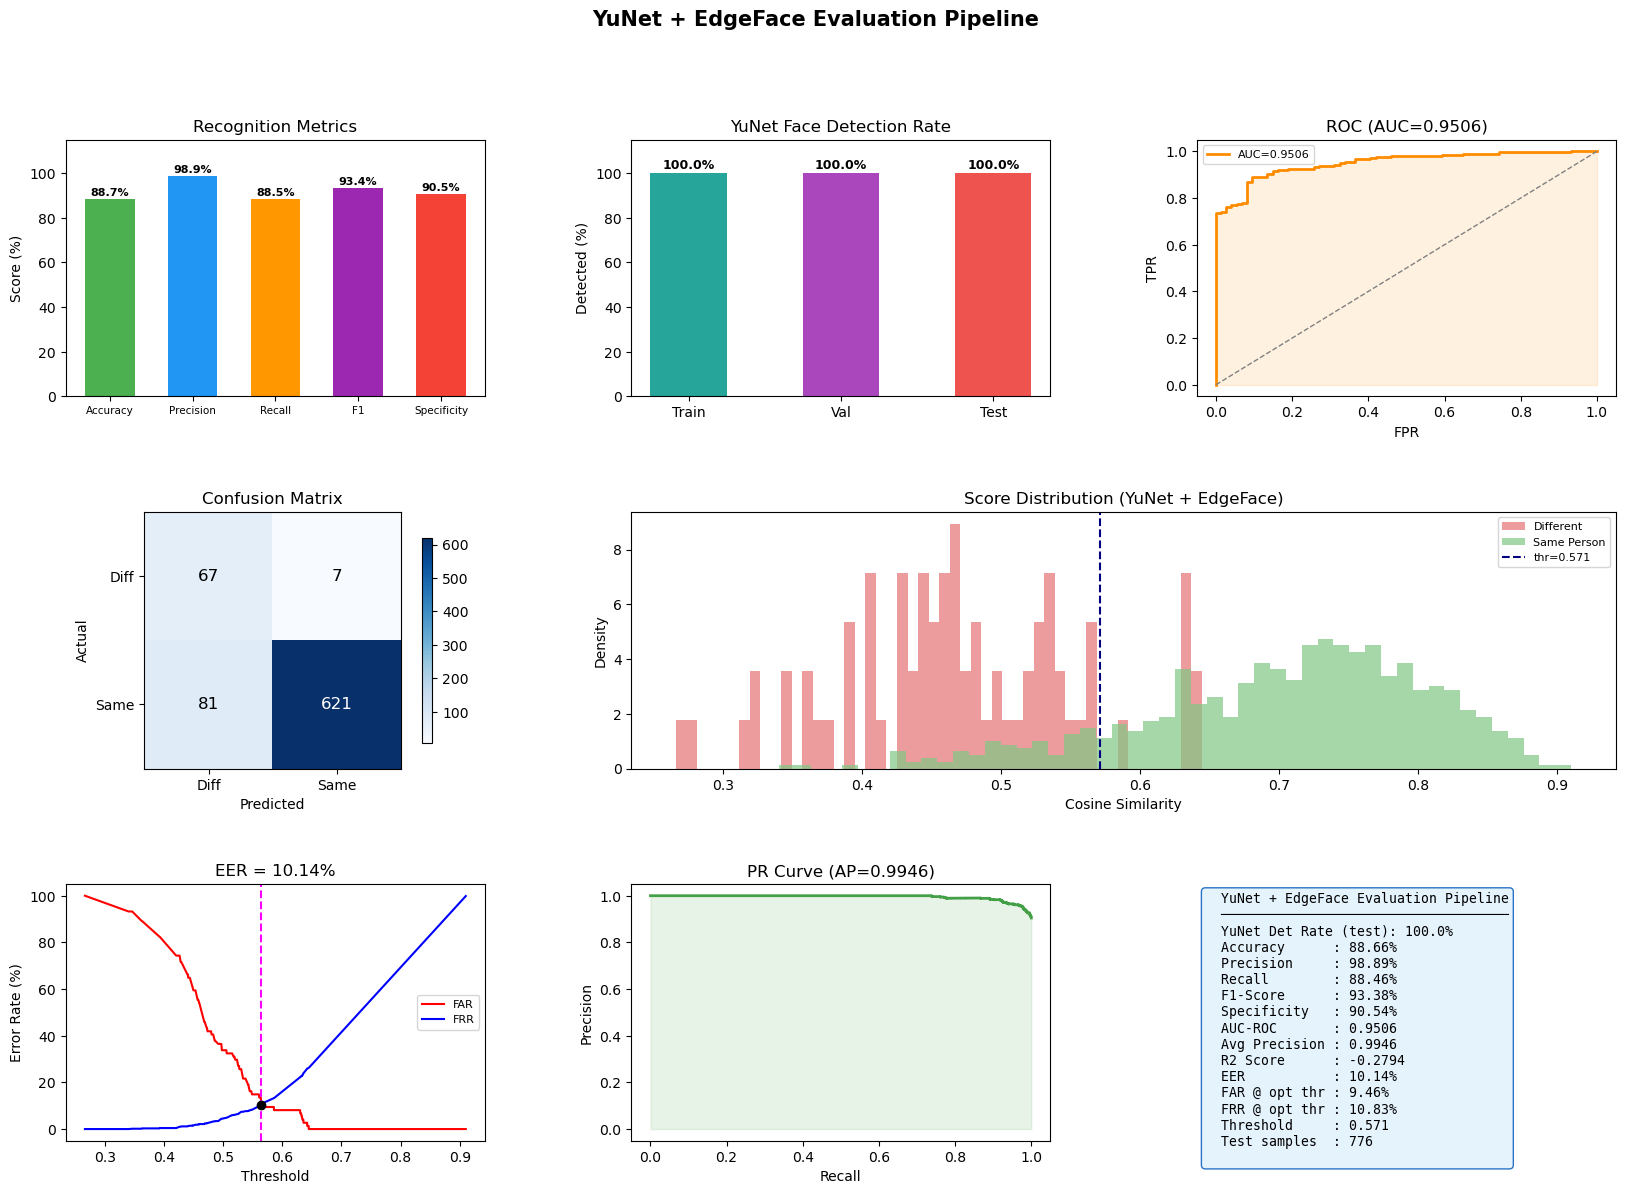

WindowsPath('eval_results/yunetedgeface_lfw_dashboard.png')

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, r2_score

def compute_eer(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    return eer, thresholds[idx], fpr, tpr, fnr, thresholds


def plot_dashboard(y_true, y_pred, scores, threshold, det_rates: dict):
    RESULTS_DIR.mkdir(exist_ok=True)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp + 1e-8)

    fpr_r, tpr_r, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr_r, tpr_r)
    p_pr, r_pr, _   = precision_recall_curve(y_true, scores)
    ap  = average_precision_score(y_true, scores)
    eer, eer_thr, fpr_e, tpr_e, fnr_e, thr_e = compute_eer(y_true, scores)
    r2  = r2_score(y_true, scores)

    dr_tr = det_rates.get("train", 0)
    dr_te = det_rates.get("test",  0)

    fig = plt.figure(figsize=(20, 13))
    fig.suptitle("YuNet + EdgeFace Evaluation Pipeline", fontsize=15, fontweight="bold")
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # 1. Classification metrics
    ax1 = fig.add_subplot(gs[0, 0])
    labels = ["Accuracy", "Precision", "Recall", "F1", "Specificity"]
    vals   = [acc, prec, rec, f1, spec]
    colors = ["#4CAF50", "#2196F3", "#FF9800", "#9C27B0", "#F44336"]
    bars   = ax1.bar(labels, [v*100 for v in vals], color=colors, width=0.6)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val*100:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax1.set_ylim(0, 115)
    ax1.set_title("Recognition Metrics")
    ax1.set_ylabel("Score (%)")
    ax1.tick_params(axis="x", labelsize=7.5)

    # 2. YuNet detection rate
    ax2 = fig.add_subplot(gs[0, 1])
    splits = ["Train", "Val", "Test"]
    drs    = [det_rates.get("train", 0), det_rates.get("val", 0), det_rates.get("test", 0)]
    bcol   = ["#26A69A", "#AB47BC", "#EF5350"]
    bars2  = ax2.bar(splits, [d*100 for d in drs], color=bcol, width=0.5)
    for bar, val in zip(bars2, drs):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val*100:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax2.set_ylim(0, 115)
    ax2.set_title("YuNet Face Detection Rate")
    ax2.set_ylabel("Detected (%)")

    # 3. ROC Curve
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(fpr_r, tpr_r, color="#FF8C00", lw=2, label=f"AUC={roc_auc:.4f}")
    ax3.plot([0, 1], [0, 1], "--", color="grey", lw=1)
    ax3.fill_between(fpr_r, tpr_r, alpha=0.12, color="#FF8C00")
    ax3.set_xlabel("FPR"); ax3.set_ylabel("TPR")
    ax3.set_title(f"ROC (AUC={roc_auc:.4f})")
    ax3.legend(fontsize=8)

    # 4. Confusion Matrix
    ax4 = fig.add_subplot(gs[1, 0])
    cm  = np.array([[tn, fp], [fn, tp]])
    im  = ax4.imshow(cm, cmap="Blues")
    ax4.set_xticks([0, 1]); ax4.set_yticks([0, 1])
    ax4.set_xticklabels(["Diff", "Same"]); ax4.set_yticklabels(["Diff", "Same"])
    ax4.set_xlabel("Predicted"); ax4.set_ylabel("Actual")
    ax4.set_title("Confusion Matrix")
    for r in range(2):
        for c in range(2):
            ax4.text(c, r, str(cm[r, c]), ha="center", va="center",
                     fontsize=12, color="white" if cm[r, c] > cm.max()/2 else "black")
    plt.colorbar(im, ax=ax4, shrink=0.8)

    # 5. Score Distribution
    ax5 = fig.add_subplot(gs[1, 1:3])
    same_s = scores[y_true == 1]
    diff_s = scores[y_true == 0]
    ax5.hist(diff_s, bins=50, color="#E57373", alpha=0.7, density=True, label="Different")
    ax5.hist(same_s, bins=50, color="#81C784", alpha=0.7, density=True, label="Same Person")
    ax5.axvline(threshold, color="navy", linestyle="--", lw=1.5, label=f"thr={threshold:.3f}")
    ax5.set_xlabel("Cosine Similarity"); ax5.set_ylabel("Density")
    ax5.set_title("Score Distribution (YuNet + EdgeFace)")
    ax5.legend(fontsize=8)

    # 6. EER Curve
    ax6 = fig.add_subplot(gs[2, 0])
    ax6.plot(thr_e, fpr_e*100, color="red",  label="FAR")
    ax6.plot(thr_e, fnr_e*100, color="blue", label="FRR")
    ax6.axvline(eer_thr, color="magenta", linestyle="--", lw=1.5)
    ax6.scatter([eer_thr], [eer*100], color="black", zorder=5)
    ax6.set_xlabel("Threshold"); ax6.set_ylabel("Error Rate (%)")
    ax6.set_title(f"EER = {eer*100:.2f}%")
    ax6.legend(fontsize=8)

    # 7. PR Curve
    ax7 = fig.add_subplot(gs[2, 1])
    ax7.step(r_pr, p_pr, color="#43A047", where="post", lw=2)
    ax7.fill_between(r_pr, p_pr, alpha=0.12, color="#43A047")
    ax7.set_xlabel("Recall"); ax7.set_ylabel("Precision")
    ax7.set_title(f"PR Curve (AP={ap:.4f})")

    # 8. Summary Box
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.axis("off")
    far_idx = np.argmin(np.abs(thr_e - threshold))
    summary = (
        f"  YuNet + EdgeFace Evaluation Pipeline\n"
        f"  {'─'*36}\n"
        f"  YuNet Det Rate (test): {dr_te*100:.1f}%\n"
        f"  Accuracy      : {acc*100:.2f}%\n"
        f"  Precision     : {prec*100:.2f}%\n"
        f"  Recall        : {rec*100:.2f}%\n"
        f"  F1-Score      : {f1*100:.2f}%\n"
        f"  Specificity   : {spec*100:.2f}%\n"
        f"  AUC-ROC       : {roc_auc:.4f}\n"
        f"  Avg Precision : {ap:.4f}\n"
        f"  R2 Score      : {r2:.4f}\n"
        f"  EER           : {eer*100:.2f}%\n"
        f"  FAR @ opt thr : {fpr_e[far_idx]*100:.2f}%\n"
        f"  FRR @ opt thr : {fnr_e[far_idx]*100:.2f}%\n"
        f"  Threshold     : {threshold:.3f}\n"
        f"  Test samples  : {len(y_true)}\n"
    )
    ax8.text(0.02, 0.97, summary, transform=ax8.transAxes,
             fontsize=9.5, verticalalignment="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#E3F2FD", alpha=0.9, edgecolor="#1565C0"))

    out = RESULTS_DIR / "yunetedgeface_lfw_dashboard.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"\n\n📊 Dashboard saved: {out}")
    plt.show()
    return out


det_rates = cache.get("yunet_det_rate", {})
plot_dashboard(y_true, y_pred, scores, threshold, det_rates)
